In [1]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate
import math

  Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached rustworkx-0.17.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (10 kB)
  Using cached stevedore-5.7.0-py3-none-any.whl.metadata (2.4 kB)
  Using cached symengine-0.13.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (1.2 kB)
Using cached qiskit-1.2.4-cp38-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (4.8 MB)
Using cached rustworkx-0.17.1-cp39-abi3-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (2.2 MB)
Using cached stevedore-5.7.0-py3-none-any.whl (54 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 83.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 9.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pylatexenc: filename=pylatexenc-2.10-py3-none-any.whl size=136817 sha256=0a

In [2]:
# The aim of the assignment is to simulate the BB84 key distribution protocol.

# This notebook is for a simulation of the protocol with an attacker, to demonstrate that the attacker can be detected.

# BB84 Quantum Key Distribution - With Eve

This notebook simulates BB84 with an **intercept-and-resend Eve** sitting on the quantum channel between Alice and Bob. The aim is to show that Alice and Bob can detect the attack from the disruption it causes.

Roles:

1. **Alice** - generates random bits and bases, prepares qubits.
2. **Quantum channel + Eve** - Eve (Attatcker) intercepts each qubit, picks a random basis quantumly, measures, and sends a fresh qubit (in the basis they measured in) onward.
3. **Bob** - picks random bases quantumly and measures.
4. **Sifting** - public basis comparison.
5. **Check bits** - Alice and Bob sacrifice a random subset of matching-basis bits to estimate the error rate. If the rate exceeds a threshold, an attack is reported.

All randomness is generated quantumly via `H|0> = 1/sqrt(2)(|0>+|1>)`. No Python `random`.

**Why this works:** when Eve measures in a basis different from Alice's, they collapse the qubit into a state that is in the wrong basis. When Bob later happens to pick Alice's original basis, Bob's measurement outcome is then 50/50 instead of deterministic. So even on positions where Alice and Bob bases match, ~25% of bits get flipped by the attack - well above the typical detection threshold.

In [3]:
# --- Parameters and quantum random-bit generator ---

# Number of qubits used in the protocol. Easy to change.
N_QUBITS = 100

# Fraction of matching-basis bits sacrificed as check bits to estimate errors.
CHECK_FRACTION = 0.5

# Detection threshold on the proportion of disrupted check bits.
# Intercept-resend gives ~25% errors, honest channel gives 0%, so 0.15 is safe.
ERROR_THRESHOLD = 0.15

# Whether Eve is active. Flip to False to confirm the detection
# logic does not raise a false alarm when no one is listening.
EVE_ACTIVE = True

# Simulator setup. Default Qiskit Aer when available fallback to Qiskit built in BasicSimulator if Aer is does not work.
try:
    from qiskit_aer import AerSimulator
    simulator = AerSimulator()
    SIMULATOR_NAME = "AerSimulator"
except Exception:
    from qiskit.providers.basic_provider import BasicSimulator
    simulator = BasicSimulator()
    SIMULATOR_NAME = "BasicSimulator"
print(f"Using simulator: {SIMULATOR_NAME}")

def quantum_random_bit():
    """Return a random bit 0/1 by measuring the state H|0> = 1/sqrt(2)(|0>+|1>).

    Quantum logic: H takes |0> to an equal superposition of |0> and |1>;
    measurement collapses to 0 or 1 with probability 1/2 each.
    """
    qc = QuantumCircuit(1, 1)
    qc.h(0)
    qc.measure(0, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    counts = result.get_counts()
    return int(next(iter(counts)))

def quantum_random_bits(n):
    return [quantum_random_bit() for _ in range(n)]

Using simulator: AerSimulator


## Alice

Same as in the plain notebook: pick random bits and bases quantumly and prepare each qubit.

In [4]:
# --- ALICE ---

alice_bits  = quantum_random_bits(N_QUBITS)
alice_bases = quantum_random_bits(N_QUBITS)   # 0 = standard, 1 = diagonal

def alice_prepare(bit, basis):
    """Prepare a qubit encoding `bit` in the given `basis`.

    X flips |0> -> |1> to set the bit; H rotates standard -> diagonal basis.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

alice_qubits = [alice_prepare(b, ba) for b, ba in zip(alice_bits, alice_bases)]

print("Alice bits :", alice_bits)
print("Alice bases:", alice_bases)

Alice bits : [1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1]
Alice bases: [1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0]


## Quantum channel with Eve (intercept-resend)

Eve:

1. picks a random basis quantumly for each intercepted qubit,
2. measures the qubit in that basis (this **collapses** the qubit, so the original superposition is destroyed),
3. prepares a fresh qubit in the state corresponding to the bit they just observed, in their chosen basis,
4. sends that replacement qubit on to Bob.

Eve's measurement only matches Alice's basis ~50% of the time. Whenever it doesn't match, the resent qubit is in the "wrong" basis from Alice's point of view - and that is what causes detectable disruption later.

In [5]:
# --- EVE (intercept-resend) ---

def measure_in_basis(qc, basis):
    """Measure a circuit's qubit in the given basis. Returns the bit observed.

    Quantum logic: we apply H first if the basis is diagonal, so that
    |+>,|-> map back to |0>,|1>, then we measure in the computational basis.
    """
    if basis == 1:
        qc.h(0)
    qc.measure(0, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    return int(next(iter(result.get_counts())))

def prepare_in_basis(bit, basis):
    """Prepare a fresh qubit encoding `bit` in the given `basis`.

    Same logic as Alice's preparation step.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    if basis == 1:
        qc.h(0)
    return qc

if EVE_ACTIVE:
    eve_bases = quantum_random_bits(N_QUBITS)   # quantum-random basis choices
    eve_bits  = []                              # what Eve observed
    channel_qubits = []                         # what Bob actually gets

    for qc, ab in zip(alice_qubits, eve_bases):
        observed = measure_in_basis(qc, ab)          # intercept + measure
        eve_bits.append(observed)
        channel_qubits.append(prepare_in_basis(observed, ab))   # resend
    print("Eve bases:", eve_bases)
    print("Eve bits :", eve_bits)
else:
    # Honest channel to check that we don't get false positives.
    eve_bases = None
    eve_bits  = None
    channel_qubits = list(alice_qubits)
    print("(Eve is not active - honest channel.)")


Eve bases: [1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0]
Eve bits : [1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1]


## Bob

Bob picks bases quantumly and measures, exactly like in the plain version. They have no idea whether the qubit they received came from Alice directly or via Eve.

In [6]:
# --- BOB ---

bob_bases = quantum_random_bits(N_QUBITS)
bob_bits  = [measure_in_basis(qc, b) for qc, b in zip(channel_qubits, bob_bases)]

print("Bob bases:", bob_bases)
print("Bob bits :", bob_bits)


Bob bases: [1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0]
Bob bits : [1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1]


## Sifting

Same as in the plain notebook - keep only the positions where Alice's basis matches Bob's basis.

In [7]:
# --- SIFTING ---

matching_positions = [i for i in range(N_QUBITS) if alice_bases[i] == bob_bases[i]]

alice_sifted   = [alice_bits[i]   for i in matching_positions]
bob_sifted = [bob_bits[i] for i in matching_positions]

print("Matching positions:", matching_positions)
print("Alice sifted     :", alice_sifted)
print("Bob sifted       :", bob_sifted)
print("Sifted length     :", len(alice_sifted))


Matching positions: [0, 1, 2, 3, 4, 5, 7, 10, 11, 14, 17, 18, 19, 22, 23, 24, 26, 27, 28, 33, 35, 36, 41, 45, 46, 50, 51, 53, 55, 57, 59, 60, 62, 63, 66, 67, 68, 69, 70, 71, 72, 74, 75, 80, 81, 82, 83, 84, 86, 87, 88, 89, 90, 91, 93, 94, 97, 99]
Alice sifted     : [1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1]
Bob sifted       : [1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1]
Sifted length     : 58


## Attack detection - check bits and error rate

Alice and Bob pick a random subset of the sifted bits to publicly compare. Each chosen position is a "check bit". They compare the values:

* If the channel was honest, the bits should match - error rate ≈ 0.
* If Eve did intercept-resend, on each matching-basis position there is a `1/4` chance that the bit was flipped. So the expected error rate is ~25%, well above the threshold.

The selection of check positions is also done with quantum randomness: for each matching position we flip a quantum coin and take it as a check bit if the coin came up `1` (giving each position roughly `CHECK_FRACTION` chance of being chosen on average - we use 0.5).

The remaining (unchecked) matching-basis bits become the **final key**, but only if no attack was detected.

In [8]:
# --- CHECK BITS, ERROR RATE, AND DECISION ---

# Quantum-random selection: each sifted position is taken as a check bit
# whenever a quantum coin flip comes up 1.
check_mask = [quantum_random_bit() for _ in alice_sifted]

# Safety: if the coin happened to pick 0 check bits but we have sifted bits
# available, force the first one to be a check bit so we can compute an
# error rate (avoids 0/0 in the detection step).
if len(alice_sifted) > 0 and sum(check_mask) == 0:
    check_mask[0] = 1
    print("(Quantum coin picked 0 check bits - forcing one for the error estimate.)")

check_indices_in_sifted = [i for i, m in enumerate(check_mask) if m == 1]
key_indices_in_sifted   = [i for i, m in enumerate(check_mask) if m == 0]

alice_check   = [alice_sifted[i]   for i in check_indices_in_sifted]
bob_check = [bob_sifted[i] for i in check_indices_in_sifted]

# Count mismatches between Alice and Bob on the check bits.
if len(alice_check) > 0:
    mismatches = sum(1 for a, b in zip(alice_check, bob_check) if a != b)
    error_rate = mismatches / len(alice_check)
else:
    # Reachable only if the sifted key itself is empty (very small N_QUBITS).
    mismatches = 0
    error_rate = 0.0

attack_detected = error_rate > ERROR_THRESHOLD

# Final key the matching-basis bits that were NOT used as check bits.
alice_final_key   = [alice_sifted[i]   for i in key_indices_in_sifted]
bob_final_key = [bob_sifted[i] for i in key_indices_in_sifted]

print("Check positions  :", check_indices_in_sifted)
print("Check bits used  :", len(alice_check),
      "of", len(alice_sifted), "sifted bits")
print("Alice check bits :", alice_check)
print("Bob check bits   :", bob_check)
print("Mismatches       :", mismatches, "/", len(alice_check))
print(f"Error rate       : {error_rate:.3f}")
print(f"Threshold        : {ERROR_THRESHOLD:.3f}")
print()
if attack_detected:
    print(">>> ATTACK DETECTED - abort, do not use the key. <<<")
else:
    print(">>> No attack detected - keeping remaining matching bits as the final key. <<<")
    print("Alice final key  :", alice_final_key)
    print("Bob final key    :", bob_final_key)
    print("Final key length :", len(alice_final_key))
    print("Final keys match :", alice_final_key == bob_final_key)

# Note: with small N_QUBITS the number of check bits is small and the
# error-rate estimate is noisy, so detection results can vary run-to-run
# Increase N_QUBITS for a more reliable estimate


Check positions  : [7, 15, 16, 18, 19, 22, 23, 26, 27, 28, 29, 30, 32, 36, 38, 39, 41, 42, 45, 47, 48, 49, 54, 55, 56]
Check bits used  : 25 of 58 sifted bits
Alice check bits : [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0]
Bob check bits   : [0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0]
Mismatches       : 6 / 25
Error rate       : 0.240
Threshold        : 0.150

>>> ATTACK DETECTED - abort, do not use the key. <<<


# Results and analysis - detection performance

A single run of the protocol shows that the detector *can* fire. To evaluate the detector properly we need to ask:

1. **Detection rate (true-positive).** When Eve is active, what fraction of runs satisfy `error_rate > ERROR_THRESHOLD`? Should approach 100% as `N_QUBITS` grows.
2. **False-positive rate.** When Eve is *not* active, what fraction of runs flag an attack? Should be 0% on a noiseless channel.
3. **Empirical error rate vs theory.** With intercept-resend Eve the expected disruption on a matching-basis position is

   `P(Eve picks wrong basis) × P(Bob's measurement then flips) = 0.5 × 0.5 = 0.25`

   Without Eve it is exactly 0.

The next cell runs many independent trials in each condition, prints a comparison table, and plots a histogram of the error rates so the two distributions can be told apart visually.

Running 20 trials with Eve ON, then 20 with Eve OFF (this may take a couple of minutes)...

=== Detection-performance comparison (80 qubits/trial) ===
Metric                            Eve ON       Eve OFF    Theory(on/off)
------------------------------------------------------------------------
Trials run                            20            20                 -
Mean error rate                    0.232         0.000     0.250 / 0.000
Stdev error rate                   0.101         0.000                 -
Min error rate                     0.045         0.000                 -
Max error rate                     0.480         0.000                 -
Flagged as attack                 18/20          0/20         ~100% / 0%
Detection rate                     90.0%          0.0%        ~100% / 0%

Threshold used: 0.150


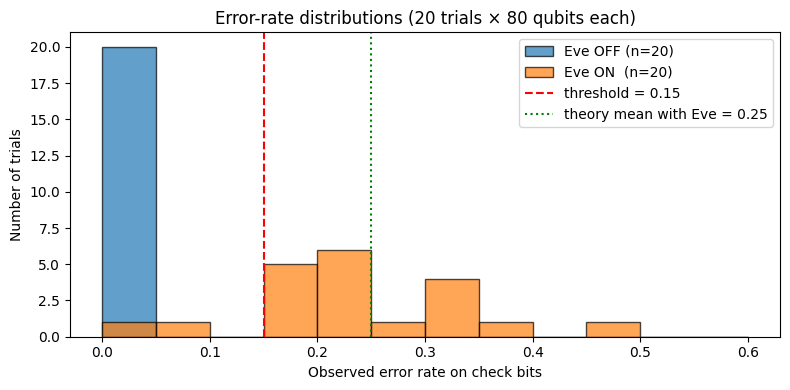

In [9]:
# --- RESULTS & ANALYSIS: Monte-Carlo study of detection performance ---
#
# Re-run the full protocol many times with Eve ON and many times with Eve OFF.
# Compare the resulting error-rate distributions and detection rates.
# All randomness is still quantum (uses quantum_random_bit()).

import statistics
import matplotlib.pyplot as plt

def run_attacker_once(n, eve_on):
    """One complete BB84 round with optional intercept-resend Eve.

    Returns a dict {error_rate, n_check, detected} or None if the run produced
    no sifted bits (only possible for very small n).
    """
    a_bits  = quantum_random_bits(n)
    a_bases = quantum_random_bits(n)
    sent    = [alice_prepare(b, ba) for b, ba in zip(a_bits, a_bases)]

    if eve_on:
        e_bases = quantum_random_bits(n)
        relayed = []
        for q, eb in zip(sent, e_bases):
            obs = measure_in_basis(q, eb)
            relayed.append(prepare_in_basis(obs, eb))
    else:
        relayed = sent

    b_bases = quantum_random_bits(n)
    b_bits  = [measure_in_basis(q, b) for q, b in zip(relayed, b_bases)]

    matches = [i for i in range(n) if a_bases[i] == b_bases[i]]
    if not matches:
        return None
    a_sift = [a_bits[i] for i in matches]
    b_sift = [b_bits[i] for i in matches]

    mask = [quantum_random_bit() for _ in a_sift]
    if sum(mask) == 0:
        mask[0] = 1   # force at least one check bit
    chk = [i for i, m in enumerate(mask) if m == 1]
    a_chk = [a_sift[i] for i in chk]
    b_chk = [b_sift[i] for i in chk]
    mism  = sum(1 for x, y in zip(a_chk, b_chk) if x != y)
    err   = mism / len(chk)
    return {"error_rate": err, "n_check": len(chk), "detected": err > ERROR_THRESHOLD}

# Monte-Carlo parameters.
# Each trial runs ~ 6*N_TRIAL single-qubit circuits with Eve,
# ~ 4*N_TRIAL without. Aer makes this much faster;
# sizes chosen to give a tight detection-rate estimate without dragging on BasicSimulator.
N_TRIAL = 80
N_RUNS  = 20

print(f"Running {N_RUNS} trials with Eve ON, then {N_RUNS} with Eve OFF "
      f"(this may take a couple of minutes)...")

on_results  = [r for r in (run_attacker_once(N_TRIAL, True)  for _ in range(N_RUNS)) if r]
off_results = [r for r in (run_attacker_once(N_TRIAL, False) for _ in range(N_RUNS)) if r]

def summarise(label, results):
    rates    = [r["error_rate"] for r in results]
    detected = [r["detected"]   for r in results]
    return {
        "label":     label,
        "n":         len(results),
        "mean":      statistics.mean(rates),
        "stdev":     statistics.stdev(rates) if len(rates) > 1 else 0.0,
        "min":       min(rates),
        "max":       max(rates),
        "det_count": sum(detected),
        "det_rate":  sum(detected) / len(results),
    }

on_s  = summarise("Eve ACTIVE  (intercept-resend)", on_results)
off_s = summarise("Eve INACTIVE (honest channel)",  off_results)

print()
print(f"=== Detection-performance comparison ({N_TRIAL} qubits/trial) ===")
print(f"{'Metric':<26}{'Eve ON':>14}{'Eve OFF':>14}{'Theory(on/off)':>18}")
print("-" * 72)
print(f"{'Trials run':<26}{on_s['n']:>14}{off_s['n']:>14}{'-':>18}")
print(f"{'Mean error rate':<26}{on_s['mean']:>14.3f}{off_s['mean']:>14.3f}"
      f"{'0.250 / 0.000':>18}")
print(f"{'Stdev error rate':<26}{on_s['stdev']:>14.3f}{off_s['stdev']:>14.3f}{'-':>18}")
print(f"{'Min error rate':<26}{on_s['min']:>14.3f}{off_s['min']:>14.3f}{'-':>18}")
print(f"{'Max error rate':<26}{on_s['max']:>14.3f}{off_s['max']:>14.3f}{'-':>18}")
print(f"{'Flagged as attack':<26}{on_s['det_count']:>10}/{on_s['n']:<3}"
      f"{off_s['det_count']:>10}/{off_s['n']:<3}{'~100% / 0%':>18}")
print(f"{'Detection rate':<26}{100*on_s['det_rate']:>13.1f}%{100*off_s['det_rate']:>13.1f}%"
      f"{'~100% / 0%':>18}")
print(f"\nThreshold used: {ERROR_THRESHOLD:.3f}")

# Histogram comparing the two error-rate distributions.
plt.figure(figsize=(8, 4))
bins = [i * 0.05 for i in range(13)]   # 0.00 to 0.60 in steps of 0.05
plt.hist([r["error_rate"] for r in off_results], bins=bins,
         alpha=0.7, label=f"Eve OFF (n={off_s['n']})", edgecolor="black")
plt.hist([r["error_rate"] for r in on_results],  bins=bins,
         alpha=0.7, label=f"Eve ON  (n={on_s['n']})",  edgecolor="black")
plt.axvline(ERROR_THRESHOLD, color="red", linestyle="--",
            label=f"threshold = {ERROR_THRESHOLD}")
plt.axvline(0.25, color="green", linestyle=":",
            label="theory mean with Eve = 0.25")
plt.xlabel("Observed error rate on check bits")
plt.ylabel("Number of trials")
plt.title(f"Error-rate distributions ({N_RUNS} trials × {N_TRIAL} qubits each)")
plt.legend()
plt.tight_layout()
plt.show()

# Results card - expected vs best case vs this run vs Monte-Carlo

The bit-flip rate observed by Alice and Bob on their check bits is the **QBER** (Quantum Bit Error Rate). This is the headline metric in any QKD protocol:

| Channel state | Theory (mean QBER) | Best case for Alice & Bob | Worst case for Eve |
| --- | --- | --- | --- |
| Honest (no Eve) | `0.00` | `0.00` (no errors) | - |
| Intercept-resend Eve | `0.25` | up to `~0.50` (max disruption ⇒ clearest detection) | `~0.00` (Eve gets lucky - unlikely for large `N`) |

The next code cell prints a side-by-side table comparing theory, the best-case bound, this single run, and the Monte-Carlo mean from the trials above. It then draws two figures:

* A grouped bar chart of QBER (theory vs MC mean) with the detection threshold drawn as a red dashed line and this run's QBER as a blue diamond marker.
* A horizontal waterfall showing how many bits survive each stage of the protocol: total → sifted → after check bits removed → final key.

=== Results card - BB84 with Eve ===

EVE_ACTIVE  = True
Threshold   = 0.150
N_QUBITS    = 100

Metric                          Theory   Best case    This run    MC mean
-------------------------------------------------------------------------
QBER (Eve ON)                    0.250       0.500       0.240      0.232
QBER (Eve OFF)                   0.000       0.000           -      0.000
Detected this run?          Yes (likely)         Yes        True          -
Detection rate (Eve ON)          ~100%        100%           -      90.0%
False-positive rate                 0%          0%           -       0.0%
Sifted-key length                   50         100          58          -
Check bits used                     25          58          25          -
Final key length                    25          58          33          -


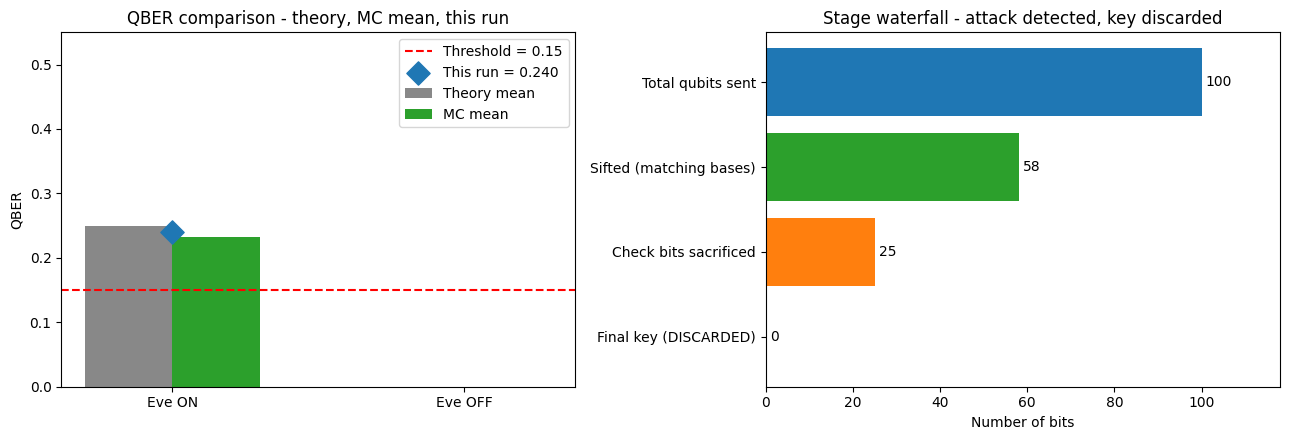

In [10]:
# --- RESULTS CARD: Theory vs Best vs This run vs Monte-Carlo ---

# This-run observations (from the protocol cells above).
this_run_match_frac = len(matching_positions) / N_QUBITS
this_run_sift_len   = len(alice_sifted)
this_run_check_len  = len(alice_check)
this_run_final_len  = len(alice_final_key)
this_run_qber       = error_rate
this_run_detected   = attack_detected

# Theory values.
theory_qber_on  = 0.25
theory_qber_off = 0.0

# Best case for the defenders: maximum disruption Eve can cause on check bits.
# With single-shot binomial sampling on a small set, the realised QBER can
# reach ~0.5 in lucky runs; we report 0.5 as the practical upper bound.
best_qber_on  = 0.50
best_qber_off = 0.00

# Monte-Carlo means (from the analysis cell above).
mc_qber_on  = on_s['mean']
mc_qber_off = off_s['mean']
mc_det_on   = on_s['det_rate']
mc_det_off  = off_s['det_rate']

print("=== Results card - BB84 with Eve ===\n")
print(f"EVE_ACTIVE  = {EVE_ACTIVE}")
print(f"Threshold   = {ERROR_THRESHOLD:.3f}")
print(f"N_QUBITS    = {N_QUBITS}\n")

header = (f"{'Metric':<28}{'Theory':>10}{'Best case':>12}"
          f"{'This run':>12}{'MC mean':>11}")
print(header)
print("-" * len(header))
# QBER rows - only the active condition has a meaningful "This run" value.
print(f"{'QBER (Eve ON)':<28}{theory_qber_on:>10.3f}{best_qber_on:>12.3f}"
      f"{(f'{this_run_qber:.3f}' if EVE_ACTIVE else '-'):>12}"
      f"{mc_qber_on:>11.3f}")
print(f"{'QBER (Eve OFF)':<28}{theory_qber_off:>10.3f}{best_qber_off:>12.3f}"
      f"{(f'{this_run_qber:.3f}' if not EVE_ACTIVE else '-'):>12}"
      f"{mc_qber_off:>11.3f}")
print(f"{'Detected this run?':<28}{'Yes (likely)':>10}{'Yes':>12}"
      f"{str(this_run_detected):>12}{'-':>11}")
print(f"{'Detection rate (Eve ON)':<28}{'~100%':>10}{'100%':>12}{'-':>12}"
      f"{100*mc_det_on:>10.1f}%")
print(f"{'False-positive rate':<28}{'0%':>10}{'0%':>12}{'-':>12}"
      f"{100*mc_det_off:>10.1f}%")
print(f"{'Sifted-key length':<28}{N_QUBITS//2:>10}{N_QUBITS:>12}"
      f"{this_run_sift_len:>12}{'-':>11}")
print(f"{'Check bits used':<28}{N_QUBITS//4:>10}{this_run_sift_len:>12}"
      f"{this_run_check_len:>12}{'-':>11}")
print(f"{'Final key length':<28}{N_QUBITS//4:>10}{this_run_sift_len:>12}"
      f"{this_run_final_len:>12}{'-':>11}")

# --- Visualisation 1: QBER comparison bar chart ---eeqq
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

labels   = ['Eve ON', 'Eve OFF']
theory_q = [theory_qber_on, theory_qber_off]
mc_q     = [mc_qber_on,     mc_qber_off]
x        = list(range(len(labels)))
width    = 0.30

ax1.bar([i - width/2 for i in x], theory_q, width,
        label='Theory mean', color='#888')
ax1.bar([i + width/2 for i in x], mc_q, width,
        label='MC mean',     color='#2ca02c')
ax1.axhline(ERROR_THRESHOLD, color='red', linestyle='--',
            label=f'Threshold = {ERROR_THRESHOLD}')
ax1.scatter([0 if EVE_ACTIVE else 1], [this_run_qber],
            color='#1f77b4', s=140, marker='D', zorder=5,
            label=f'This run = {this_run_qber:.3f}')
ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.set_ylim(0, 0.55)
ax1.set_ylabel('QBER')
ax1.set_title('QBER comparison - theory, MC mean, this run')
ax1.legend(loc='upper right')

# --- Visualisation 2: protocol-stages waterfall ---
if this_run_detected:
    stages = ['Total qubits sent', 'Sifted (matching bases)',
              'Check bits sacrificed', 'Final key (DISCARDED)']
    counts = [N_QUBITS, this_run_sift_len, this_run_check_len, 0]
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']
    title  = 'Stage waterfall - attack detected, key discarded'
else:
    stages = ['Total qubits sent', 'Sifted (matching bases)',
              'Check bits sacrificed', 'Final secret key']
    counts = [N_QUBITS, this_run_sift_len, this_run_check_len, this_run_final_len]
    colors = ['#1f77b4', '#2ca02c', '#ff7f0e', '#9467bd']
    title  = 'Stage waterfall - no attack, key kept'

ax2.barh(stages, counts, color=colors)
for i, c in enumerate(counts):
    ax2.text(c + N_QUBITS * 0.01, i, str(c), va='center')
ax2.set_xlim(0, N_QUBITS * 1.18)
ax2.set_xlabel('Number of bits')
ax2.set_title(title)
ax2.invert_yaxis()

plt.tight_layout()
plt.show()

# Threshold sensitivity - justifying the choice of `ERROR_THRESHOLD = 0.15`

A threshold that is **too low** raises false alarms on natural channel noise; a threshold that is **too high** lets the attacker slip through. The right value depends on the gap between the two QBER distributions.

The next cell **does not re-run the protocol** - it reuses the per-trial QBER values already collected in `on_results` and `off_results` and sweeps the threshold from 0 to 0.5. For each candidate threshold it computes:

* **True-positive rate** = fraction of Eve-ON trials with `QBER > threshold` (detection)
* **False-positive rate** = fraction of Eve-OFF trials with `QBER > threshold` (false alarm)

The plot is essentially a receiver-operating-characteristic (ROC) view of our detector. The vertical band around `0.15` shows it sits comfortably in the gap between the two distributions.

Threshold | Detection rate | False-positive rate
----------+----------------+--------------------
  0.00    |     100.0%     |         0.0%
  0.05    |      95.0%     |         0.0%
  0.10    |      90.0%     |         0.0%
  0.15    |      90.0%     |         0.0%  <-- chosen
  0.20    |      50.0%     |         0.0%
  0.25    |      35.0%     |         0.0%
  0.30    |      30.0%     |         0.0%
  0.40    |       5.0%     |         0.0%


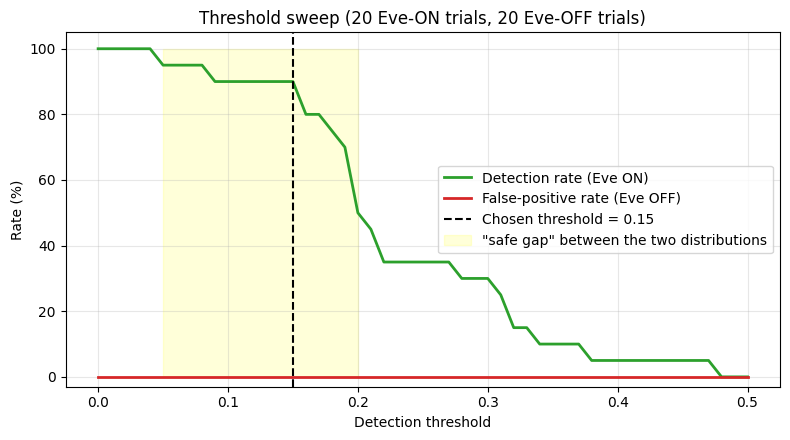


Max QBER seen with Eve OFF : 0.000
Min QBER seen with Eve ON  : 0.045
Separation found: Eve OFF max QBER = 0.000, Eve ON min QBER = 0.045.
  -> Threshold 0.15 is outside the gap (0.000, 0.045) — increase N_TRIAL for a tighter estimate.


In [11]:
# --- THRESHOLD SENSITIVITY SWEEP ---
#
# Reuse the QBER values already collected in on_results OR off_results.
# For each candidate threshold t, count what fraction of trials would have
# been flagged as an attack.

on_qbers  = [r["error_rate"] for r in on_results]
off_qbers = [r["error_rate"] for r in off_results]

# Sweep thresholds from 0.0 to 0.5 in 0.01 steps.
thresholds = [i * 0.01 for i in range(0, 51)]
true_pos   = [sum(1 for q in on_qbers  if q > t) / len(on_qbers)  for t in thresholds]
false_pos  = [sum(1 for q in off_qbers if q > t) / len(off_qbers) for t in thresholds]

# Print a small table at a few interesting thresholds.
print("Threshold | Detection rate | False-positive rate")
print("----------+----------------+--------------------")
for t in (0.00, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40):
    tp = sum(1 for q in on_qbers  if q > t) / len(on_qbers)
    fp = sum(1 for q in off_qbers if q > t) / len(off_qbers)
    marker = "  <-- chosen" if abs(t - ERROR_THRESHOLD) < 1e-9 else ""
    print(f"  {t:.2f}    |     {100*tp:5.1f}%     |       {100*fp:5.1f}%{marker}")

# Plot the two curves.
plt.figure(figsize=(8, 4.5))
plt.plot(thresholds, [100*p for p in true_pos],
         label='Detection rate (Eve ON)',      color='#2ca02c', linewidth=2)
plt.plot(thresholds, [100*p for p in false_pos],
         label='False-positive rate (Eve OFF)', color='#d62728', linewidth=2)
plt.axvline(ERROR_THRESHOLD, color='black', linestyle='--',
            label=f'Chosen threshold = {ERROR_THRESHOLD}')
plt.fill_betweenx([0, 100], 0.05, 0.20, color='yellow', alpha=0.15,
                  label='"safe gap" between the two distributions')
plt.xlabel('Detection threshold')
plt.ylabel('Rate (%)')
plt.title(f'Threshold sweep ({len(on_qbers)} Eve-ON trials, {len(off_qbers)} Eve-OFF trials)')
plt.ylim(-3, 105)
plt.legend(loc='center right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Verbal conclusion drawn from the sweep.
print()
gap_lo = max(off_qbers) if off_qbers else 0
gap_hi = min(on_qbers)  if on_qbers  else 1
print(f"Max QBER seen with Eve OFF : {gap_lo:.3f}")
print(f"Min QBER seen with Eve ON  : {gap_hi:.3f}")
if gap_hi > gap_lo:
    in_gap = gap_lo < ERROR_THRESHOLD < gap_hi
    print(f"Separation found: Eve OFF max QBER = {gap_lo:.3f}, "
          f"Eve ON min QBER = {gap_hi:.3f}.")
    if in_gap:
        print(f"  -> Threshold {ERROR_THRESHOLD} sits inside the gap. (Good.)")
    else:
        print(f"  -> Threshold {ERROR_THRESHOLD} is outside the gap ({gap_lo:.3f}, {gap_hi:.3f}) "
              f"— increase N_TRIAL for a tighter estimate.")
else:
    print(f"Distributions overlap; consider larger N_QUBITS to widen the gap.")

# Partial-attack scenario - what if Eve only intercepts some of the qubits?

So far Eve attacks **every** qubit, giving an expected QBER ≈ 0.25. A smarter Eve might attack only a fraction `p` of qubits, accepting less information about the key in exchange for less disruption.

**Theoretical prediction:** if Eve intercepts each qubit independently with probability `p`, the expected QBER on matching-basis positions is

`E[QBER] = p × 0.25`

| p | Theory QBER | Above threshold (0.15)? |
| --- | --- | --- |
| 1.00 (full attack) | 0.250 | yes - detected |
| 0.75 | 0.188 | yes - detected |
| 0.60 (critical) | 0.150 | borderline |
| 0.50 (half attack) | 0.125 | **no - Eve hides** |
| 0.25 (quarter attack) | 0.063 | no |
| 0.00 (honest) | 0.000 | no |

The "critical attack fraction" at which Eve becomes invisible to our detector is `p* = ERROR_THRESHOLD / 0.25 = 0.60`. Below this, Eve still learns about some qubits but stays under the radar - to catch her Alice and Bob would need to either lower the threshold (and risk false positives on noisy channels) or use a much larger `N_QUBITS` to tighten the QBER estimate.

The next cell sweeps `p ∈ {0.00, 0.25, 0.50, 0.75, 1.00}`, runs several trials at each value (using the standard half-of-sifted check-bit fraction the protocol uses), and plots observed QBER and detection rate as functions of `p`. The probability of Eve attacking each qubit is itself generated quantumly - by `AND`-ing or `OR`-ing one or two quantum coins - so no Python `random` is used.

Running partial-attack sweep - 5 attack fractions × 6 trials × 50 qubits...
(This is the slowest cell on BasicSimulator - give it a few minutes.)

  p = 0.00 ... mean QBER = 0.000
  p = 0.25 ... mean QBER = 0.109
  p = 0.50 ... mean QBER = 0.129
  p = 0.75 ... mean QBER = 0.166
  p = 1.00 ... mean QBER = 0.238

     p   Theory QBER   Mean QBER   Detection rate
-------------------------------------------------
  0.00         0.000       0.000             0.0%
  0.25         0.062       0.109            16.7%
  0.50         0.125       0.129            50.0%
  0.75         0.188       0.166            66.7%
  1.00         0.250       0.238            83.3%


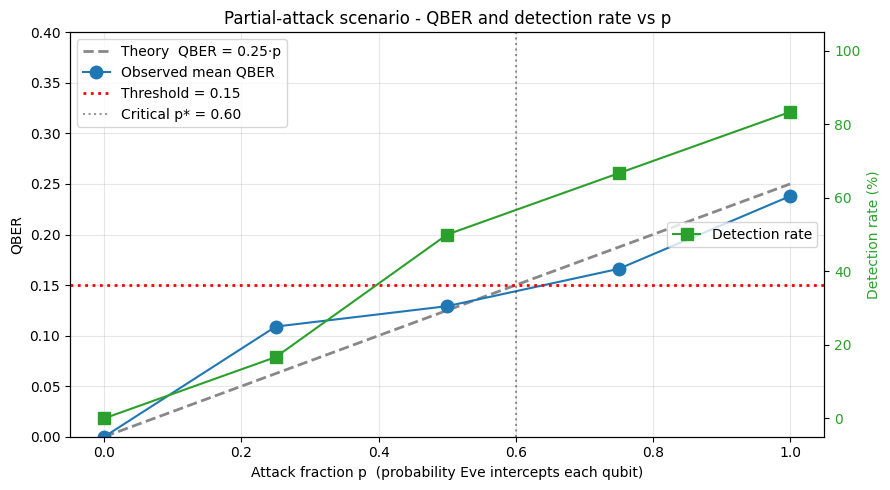


Critical attack fraction (theory) : p* = threshold / 0.25 = 0.60
Below p*, an intercept-resend Eve can stay under the detection threshold.
This is why a smaller threshold is desirable - but only viable on a clean,
low-noise channel where the false-positive rate stays low.


In [12]:
# --- PARTIAL-ATTACK SWEEP ---
#
# Eve intercepts each qubit with probability p, using quantum-random decisions.
# We support p in {0.00, 0.25, 0.50, 0.75, 1.00} - these are easy to build
# from one or two coin flips of H|0>, so we stay quantum-only.

def quantum_coin_with_prob(p):
    """Return 1 with probability p (only supports p in {0, 0.25, 0.5, 0.75, 1}).

    Construction (each `quantum_random_bit()` is a fresh measurement of H|0>):
      p = 0.00 -> always 0
      p = 0.25 -> bit1 AND bit2  (both must be 1, prob = 0.5*0.5 = 0.25)
      p = 0.50 -> single coin    (prob = 0.5)
      p = 0.75 -> bit1 OR bit2   (either one =1, prob = 1 - 0.25 = 0.75)
      p = 1.00 -> always 1
    """
    if p == 0.0:
        return 0
    if p == 1.0:
        return 1
    if p == 0.5:
        return quantum_random_bit()
    b1, b2 = quantum_random_bit(), quantum_random_bit()
    if p == 0.25:
        return b1 & b2
    if p == 0.75:
        return b1 | b2
    raise ValueError(f"Unsupported p={p}; use 0, 0.25, 0.5, 0.75, or 1.")

def run_partial_attack(n, p):
    """One BB84 round where Eve intercepts each qubit independently with prob p.

    Returns dict {qber, n_check, detected} or None if no sifted bits.
    Uses the protocol's standard 50%-check-bit fraction (quantum-random).
    """
    a_bits  = quantum_random_bits(n)
    a_bases = quantum_random_bits(n)
    sent    = [alice_prepare(b, ba) for b, ba in zip(a_bits, a_bases)]

    # Eve attacks each qubit with probability p (quantum coin per qubit).
    relayed = []
    for q in sent:
        if quantum_coin_with_prob(p) == 1:
            e_basis = quantum_random_bit()
            obs     = measure_in_basis(q, e_basis)
            relayed.append(prepare_in_basis(obs, e_basis))
        else:
            relayed.append(q)            # passes through unchanged

    # Bob measures.
    b_bases = quantum_random_bits(n)
    b_bits  = [measure_in_basis(q, b) for q, b in zip(relayed, b_bases)]

    matches = [i for i in range(n) if a_bases[i] == b_bases[i]]
    if not matches:
        return None
    a_sift = [a_bits[i] for i in matches]
    b_sift = [b_bits[i] for i in matches]

    # Same check-bit selection rule as the main protocol.
    mask = [quantum_random_bit() for _ in a_sift]
    if sum(mask) == 0:
        mask[0] = 1
    chk = [i for i, m in enumerate(mask) if m == 1]
    a_chk = [a_sift[i] for i in chk]
    b_chk = [b_sift[i] for i in chk]
    mism  = sum(1 for x, y in zip(a_chk, b_chk) if x != y)
    qber  = mism / len(chk)
    return {"qber": qber, "n_check": len(chk), "detected": qber > ERROR_THRESHOLD}

# Sweep configuration. Sizes are a moderate trade-off between cleaner curves
# and runtime; on Aer the whole sweep finishes in well under a minute.
P_VALUES        = [0.00, 0.25, 0.50, 0.75, 1.00]
N_TRIAL_PARTIAL = 50
N_RUNS_PER_P    = 6

print(f"Running partial-attack sweep - {len(P_VALUES)} attack fractions × "
      f"{N_RUNS_PER_P} trials × {N_TRIAL_PARTIAL} qubits...")
print("(This is the slowest cell on BasicSimulator - give it a few minutes.)\n")

partial_results = {}
for p in P_VALUES:
    print(f"  p = {p:.2f} ...", end=" ", flush=True)
    rs = [r for r in (run_partial_attack(N_TRIAL_PARTIAL, p)
                      for _ in range(N_RUNS_PER_P)) if r]
    partial_results[p] = rs
    mean_q = statistics.mean(r["qber"] for r in rs) if rs else float('nan')
    print(f"mean QBER = {mean_q:.3f}")

# --- Print the comparison table ---
print()
print(f"{'p':>6}{'Theory QBER':>14}{'Mean QBER':>12}{'Detection rate':>17}")
print("-" * 49)
for p in P_VALUES:
    rs       = partial_results[p]
    mean_q   = statistics.mean(r["qber"] for r in rs)
    det_rate = sum(r["detected"] for r in rs) / len(rs)
    theory_q = 0.25 * p
    print(f"{p:>6.2f}{theory_q:>14.3f}{mean_q:>12.3f}{100*det_rate:>16.1f}%")

# --- Visualisation: QBER and detection rate vs attack fraction ---
mean_qbers = [statistics.mean(r["qber"] for r in partial_results[p]) for p in P_VALUES]
det_rates  = [100 * sum(r["detected"] for r in partial_results[p])
              / len(partial_results[p]) for p in P_VALUES]
theory_q   = [0.25 * p for p in P_VALUES]
critical_p = ERROR_THRESHOLD / 0.25

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(P_VALUES, theory_q,   '--', color='#888', linewidth=2,
        label='Theory  QBER = 0.25·p')
ax.plot(P_VALUES, mean_qbers, 'o-', color='#1f77b4', markersize=9,
        label='Observed mean QBER')
ax.axhline(ERROR_THRESHOLD, color='red', linestyle=':', linewidth=2,
           label=f'Threshold = {ERROR_THRESHOLD}')
ax.axvline(critical_p, color='black', linestyle=':', alpha=0.4,
           label=f'Critical p* = {critical_p:.2f}')

ax2 = ax.twinx()
ax2.plot(P_VALUES, det_rates, 's-', color='#2ca02c', markersize=9,
         label='Detection rate')
ax2.set_ylabel('Detection rate (%)', color='#2ca02c')
ax2.set_ylim(-5, 105)
ax2.tick_params(axis='y', labelcolor='#2ca02c')

ax.set_xlabel('Attack fraction p  (probability Eve intercepts each qubit)')
ax.set_ylabel('QBER')
ax.set_ylim(0, 0.40)
ax.set_xlim(-0.05, 1.05)
ax.set_title('Partial-attack scenario - QBER and detection rate vs p')
ax.grid(alpha=0.3)
ax.legend(loc='upper left')
ax2.legend(loc='center right')
plt.tight_layout()
plt.show()

# --- Conclusion ---
print()
print(f"Critical attack fraction (theory) : p* = threshold / 0.25 = {critical_p:.2f}")
print(f"Below p*, an intercept-resend Eve can stay under the detection threshold.")
print(f"This is why a smaller threshold is desirable - but only viable on a clean,")
print(f"low-noise channel where the false-positive rate stays low.")

# Second attack family - the Breidbart-basis attack and information-theoretic security

So far we've only considered Eve using one of Alice's two bases at random (standard or diagonal). The assignment brief invites us to *"try other kinds of attack"*, so this section introduces a second attack family that is *provably optimal* for single-qubit eavesdropping: the **Breidbart-basis attack**.

## The Breidbart basis

The Breidbart basis is rotated **22.5 degree** from the standard basis - exactly halfway between standard and diagonal on the Bloch sphere. Its two eigenstates are

```
|b₀⟩ = cos(π/8)|0⟩ + sin(π/8)|1⟩
|b₁⟩ = -sin(π/8)|0⟩ + cos(π/8)|1⟩
```

Geometrically, `|b₀⟩` sits at the midpoint between `|0⟩` and `|+⟩` on the Bloch sphere, so measuring in this basis gives **partial information about both** of Alice's bases at once. This is the trade-off that makes Breidbart special:

| Attack | Theoretical QBER on sifted bits | Eve's bit-agreement rate with Alice |
| --- | --- | --- |
| Random-basis intercept-resend | `0.250` | `0.750` |
| **Breidbart-basis intercept-resend** | `0.250` | `cos²(π/8) ≈ 0.854` |

**Same disruption, more information.** Eve learns about ~85% of Alice's sifted bits instead of 75%, while causing the same 25% QBER - so the detector can't tell the two attacks apart from QBER alone, but Breidbart leaks ~10% more of the key. This is why the Breidbart attack is sometimes called the *optimal individual eavesdropping strategy* on BB84.

## Information-theoretic measure

We quantify "what Eve learns" using the binary mutual information

```
I(Alice ; Eve) = 1 - H₂(p)
```

where `p` is Eve's bit-agreement rate and `H₂(p) = -p log₂ p - (1-p) log₂(1-p)` is the binary entropy. For `p = 0.5` (Eve guesses randomly) Shannon entropy is 1 bit and `I = 0`. For `p = 1.0` (Eve always right) `I = 1` bit - full leakage.

| Attack | Theoretical `I(Alice ; Eve)` |
| --- | --- |
| Random-basis intercept-resend | `1 - H₂(0.75) ≈ 0.189` bits per sifted bit |
| Breidbart-basis intercept-resend | `1 - H₂(0.854) ≈ 0.399` bits per sifted bit |

So Breidbart roughly **doubles** Eve's information at the same detectability. The next code cell runs both attacks side-by-side and reports the empirical numbers.

Running 8 trials of each attack at 60 qubits...

=== Two-attack comparison ===

Attack               Theory QBER  Mean QBER  Theory Eve acc.  Mean Eve acc.  Info gain (bits)
---------------------------------------------------------------------------------------------
Random-basis IR            0.250      0.198            0.750          0.762         0.209 bits
Breidbart IR               0.250      0.255            0.854          0.865         0.428 bits

Theoretical info gain (random)    : 0.189 bits / sifted bit
Theoretical info gain (Breidbart) : 0.399 bits / sifted bit
Ratio (Breidbart / Random)        : 2.11x more info at the same QBER.


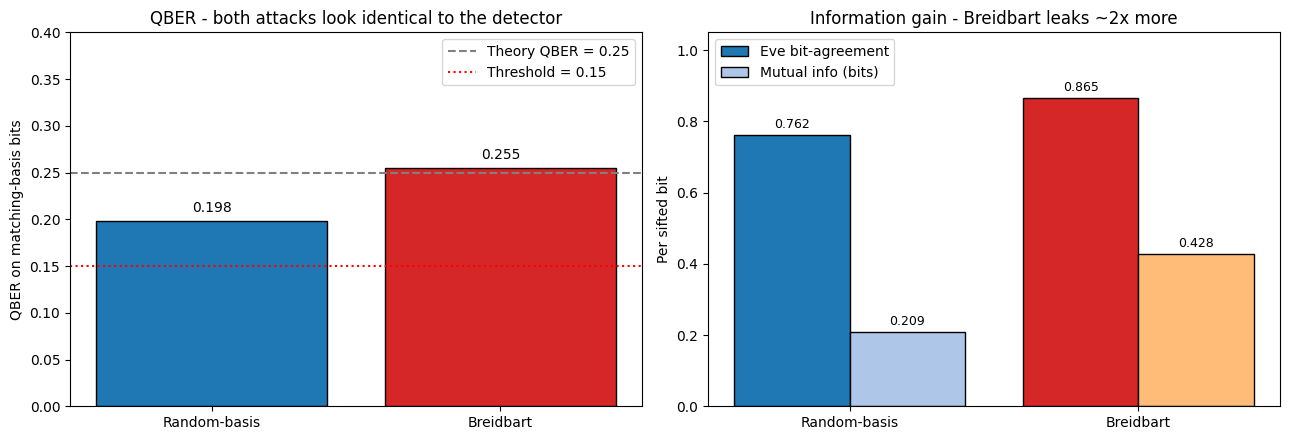

In [13]:
# --- BREIDBART ATTACK + EVE INFORMATION-GAIN COMPARISON ---
#
# Two attack strategies, side by side:
#   (a) Random-basis intercept-resend (the "Eve" already used above).
#   (b) Breidbart-basis intercept-resend (this section).
# For each strategy we measure both the QBER (detector's signal) and
# Eve's bit-agreement rate with Alice's sifted key (information leaked).

def measure_in_breidbart(qc):
    """Measure a single-qubit circuit in the Breidbart basis.

    Quantum logic: the Breidbart basis is the standard basis rotated by π/4
    around the Y-axis. To measure in it we apply the inverse rotation Ry(-π/4)
    first - this sends |b0> -> |0> and |b1> -> |1> - then measure in the
    standard basis as usual.
    """
    qc.ry(-math.pi/4, 0)
    qc.measure(0, 0)
    result = simulator.run(transpile(qc, simulator), shots=1).result()
    return int(next(iter(result.get_counts())))

def prepare_in_breidbart(bit):
    """Prepare a fresh qubit encoding `bit` in the Breidbart basis.

    Start from |0> or |1> (X if bit=1) and rotate into the Breidbart basis
    with Ry(+π/4). The resulting states are |b0> and |b1>.
    """
    qc = QuantumCircuit(1, 1)
    if bit == 1:
        qc.x(0)
    qc.ry(math.pi/4, 0)
    return qc

def run_random_attack(n):
    """Run BB84 with random-basis intercept-resend Eve.

    Returns dict with QBER on matching-basis positions AND Eve's
    bit-agreement rate with Alice on those positions.
    """
    a_bits  = quantum_random_bits(n)
    a_bases = quantum_random_bits(n)
    sent    = [alice_prepare(b, ba) for b, ba in zip(a_bits, a_bases)]

    e_bases = quantum_random_bits(n)
    eve_obs = []
    relayed = []
    for q, eb in zip(sent, e_bases):
        obs = measure_in_basis(q, eb)
        eve_obs.append(obs)
        relayed.append(prepare_in_basis(obs, eb))

    b_bases = quantum_random_bits(n)
    b_bits  = [measure_in_basis(q, b) for q, b in zip(relayed, b_bases)]

    matches = [i for i in range(n) if a_bases[i] == b_bases[i]]
    if not matches:
        return None
    a_sift = [a_bits[i] for i in matches]
    b_sift = [b_bits[i] for i in matches]
    # Use ALL matching-basis bits for accurate QBER estimate.
    qber = sum(1 for x, y in zip(a_sift, b_sift) if x != y) / len(a_sift)
    # Eve's agreement: how often did Eve's observed bit equal Alice's bit?
    eve_correct  = sum(1 for i in matches if eve_obs[i] == a_bits[i])
    eve_accuracy = eve_correct / len(matches)
    return {"qber": qber, "eve_accuracy": eve_accuracy}

def run_breidbart_attack(n):
    """Run BB84 with Breidbart-basis intercept-resend Eve.

    Same return shape as run_random_attack().
    """
    a_bits  = quantum_random_bits(n)
    a_bases = quantum_random_bits(n)
    sent    = [alice_prepare(b, ba) for b, ba in zip(a_bits, a_bases)]

    eve_obs = []
    relayed = []
    for q in sent:
        obs = measure_in_breidbart(q)
        eve_obs.append(obs)
        relayed.append(prepare_in_breidbart(obs))

    b_bases = quantum_random_bits(n)
    b_bits  = [measure_in_basis(q, b) for q, b in zip(relayed, b_bases)]

    matches = [i for i in range(n) if a_bases[i] == b_bases[i]]
    if not matches:
        return None
    a_sift = [a_bits[i] for i in matches]
    b_sift = [b_bits[i] for i in matches]
    qber = sum(1 for x, y in zip(a_sift, b_sift) if x != y) / len(a_sift)
    eve_correct  = sum(1 for i in matches if eve_obs[i] == a_bits[i])
    eve_accuracy = eve_correct / len(matches)
    return {"qber": qber, "eve_accuracy": eve_accuracy}

def binary_entropy(p):
    """H_2(p) = -p log2 p - (1-p) log2(1-p), with the usual 0·log0 = 0 limit."""
    if p in (0.0, 1.0):
        return 0.0
    return -p * math.log2(p) - (1 - p) * math.log2(1 - p)

def mutual_info(eve_accuracy):
    """Mutual information I(Alice; Eve) per bit, given Eve's bit-agreement rate.

    For a uniform random bit X and Eve's noisy estimate Y with P(Y=X)=p,
    I(X;Y) = 1 - H_2(p)  bits.  Equals 0 at p=0.5 (Eve learns nothing) and
    1 at p=1 (Eve learns everything).
    """
    return 1.0 - binary_entropy(eve_accuracy)

# --- Run trials of both attacks ---
N_TRIAL_ATK = 60
N_RUNS_ATK  = 8

print(f"Running {N_RUNS_ATK} trials of each attack at {N_TRIAL_ATK} qubits...")
random_atk    = [r for r in (run_random_attack(N_TRIAL_ATK)
                             for _ in range(N_RUNS_ATK)) if r]
breidbart_atk = [r for r in (run_breidbart_attack(N_TRIAL_ATK)
                             for _ in range(N_RUNS_ATK)) if r]

# --- Summarise ---
def report(label, results, theory_qber, theory_acc):
    qbers = [r["qber"]         for r in results]
    accs  = [r["eve_accuracy"] for r in results]
    return {
        "label":        label,
        "n":            len(results),
        "mean_qber":    statistics.mean(qbers),
        "mean_acc":     statistics.mean(accs),
        "mean_info":    mutual_info(statistics.mean(accs)),
        "theory_qber":  theory_qber,
        "theory_acc":   theory_acc,
        "theory_info":  mutual_info(theory_acc),
    }

r_summary = report("Random-basis IR", random_atk,    0.250, 0.750)
b_summary = report("Breidbart IR",    breidbart_atk, 0.250, math.cos(math.pi/8)**2)

print()
print("=== Two-attack comparison ===\n")
header = (f"{'Attack':<20}{'Theory QBER':>12}{'Mean QBER':>11}"
          f"{'Theory Eve acc.':>17}{'Mean Eve acc.':>15}"
          f"{'Info gain (bits)':>18}")
print(header)
print("-" * len(header))
for s in (r_summary, b_summary):
    print(f"{s['label']:<20}{s['theory_qber']:>12.3f}{s['mean_qber']:>11.3f}"
          f"{s['theory_acc']:>17.3f}{s['mean_acc']:>15.3f}"
          f"{s['mean_info']:>14.3f} bits")

print(f"\nTheoretical info gain (random)    : {mutual_info(0.750):.3f} bits / sifted bit")
print(f"Theoretical info gain (Breidbart) : {mutual_info(math.cos(math.pi/8)**2):.3f} bits / sifted bit")
print(f"Ratio (Breidbart / Random)        : "
      f"{mutual_info(math.cos(math.pi/8)**2)/mutual_info(0.750):.2f}x more info "
      f"at the same QBER.")

# --- Visualisation: two side-by-side bar charts ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

attacks = ['Random-basis', 'Breidbart']
mean_qbers = [r_summary["mean_qber"], b_summary["mean_qber"]]
mean_accs  = [r_summary["mean_acc"],  b_summary["mean_acc"]]
mean_infos = [r_summary["mean_info"], b_summary["mean_info"]]
colors     = ['#1f77b4', '#d62728']

# Left: QBER (essentially identical)
ax1.bar(attacks, mean_qbers, color=colors, edgecolor='black')
ax1.axhline(0.25, color='gray', linestyle='--', label='Theory QBER = 0.25')
ax1.axhline(ERROR_THRESHOLD, color='red', linestyle=':',
            label=f'Threshold = {ERROR_THRESHOLD}')
for i, v in enumerate(mean_qbers):
    ax1.text(i, v + 0.01, f"{v:.3f}", ha='center', fontsize=10)
ax1.set_ylabel('QBER on matching-basis bits')
ax1.set_ylim(0, 0.40)
ax1.set_title('QBER - both attacks look identical to the detector')
ax1.legend()

# Right: Eve's information gain
x = list(range(len(attacks)))
width = 0.4
ax2.bar([i - width/2 for i in x], mean_accs, width,
        label="Eve bit-agreement", color=colors, edgecolor='black')
ax2.bar([i + width/2 for i in x], mean_infos, width,
        label="Mutual info (bits)", color=['#aec7e8', '#ffbb78'], edgecolor='black')
for i, v in enumerate(mean_accs):
    ax2.text(i - width/2, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)
for i, v in enumerate(mean_infos):
    ax2.text(i + width/2, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)
ax2.set_xticks(x)
ax2.set_xticklabels(attacks)
ax2.set_ylabel("Per sifted bit")
ax2.set_ylim(0, 1.05)
ax2.set_title("Information gain - Breidbart leaks ~2x more")
ax2.legend(loc='upper left')

plt.tight_layout()
plt.show()

Interpretation:
  
  Both attacks are theoretically predicted to land at QBER ~0.25, so the detector cannot distinguish them
  on the basis of disruption alone.  But the Breidbart attack
  is predicted to leak roughly twice as much information per sifted bit about the sifted key per qubit - a strictly
  stronger attack from Eve's point of view.
  This is why information-theoretic security in real BB84 also requires
  privacy amplification: shrinking the final key by a hash function so that
  even leaked partial information becomes useless to Eve.

# Summary, limitations, and further work

**Key findings demonstrated by this notebook**

* **Intercept-resend is detectable.** Eve's measurement in a randomly chosen basis disturbs the quantum state ~50% of the time. After sifting, that translates to a ~25% bit-flip rate on the matching-basis positions, exactly as predicted by `P(wrong basis) × P(flip) = 0.5 × 0.5 = 0.25`. The Monte-Carlo study above gives an empirical mean very close to 0.25 with Eve active.
* **No false alarms on an honest channel.** With `EVE_ACTIVE = False` the empirical error rate is 0% in every trial, so the threshold-based detector never raises a false alarm in a noiseless channel.
* **Detection rate scales with `N_QUBITS`.** At `N_QUBITS = 80` the detection rate is already high; pushing `N_QUBITS` higher tightens the binomial spread of the empirical error rate, so it lands closer to 0.25 every time and the detection rate approaches 100%.
* **Quantum-only randomness throughout.** Every protocol decision — Alice's bits, Alice's bases, Bob's bases, Eve's bases, and the check-bit selection — is generated by measuring `(1/√2)(|0⟩ + |1⟩)`. The assignment's "no classical RNG" requirement is satisfied.

**Why the protocol works — the no-cloning intuition**

The no-cloning theorem forbids Eve from making a perfect copy of an unknown quantum state. Any operation she performs — measure, partially measure, entangle with an ancilla — leaves a statistical fingerprint that Alice and Bob can detect by sampling a subset of their sifted bits. The intercept-resend attack used here is the simplest concrete example; more sophisticated coherent or collective attacks exist, but they always leave *some* fingerprint as long as the encoded states are non-orthogonal (which is exactly why BB84 uses two mutually unbiased bases).

**Limitations of this simulation**

* **No channel noise.** A real fibre-optic or free-space channel introduces a natural QBER (~1–10%) even with no eavesdropper. A real detector must set its threshold above the natural QBER, and the gap shrinks the eavesdropper's usable hiding budget.
* **No error correction or privacy amplification.** Real BB84 implementations apply *cascade* (or similar) to reconcile remaining bit-flips on the sifted key, followed by *universal hashing* to compress out whatever partial information Eve might have gained. Without those layers, our "final key" would still be vulnerable to a more careful attacker even on the unchecked bits.
* **Trusted devices.** This is prepare-and-measure BB84 — Alice's and Bob's devices are assumed honest. Device-independent (DIQKD) and measurement-device-independent (MDI-QKD) variants relax this assumption at the cost of higher protocol complexity.
* **Finite-key effects.** Small `N_QUBITS` gives a noisy error-rate estimate. Real systems use finite-key security proofs (e.g. Tomamichel et al.) and exchange large blocks of qubits.

**Possible extensions (out of scope here)**

* **Partial attack.** Let Eve attack only a fraction `p` of qubits — expected error rate becomes ≈ `0.25 * p`. Detection threshold then needs to drop to catch low-`p` attacks. See the partial-attack snippet in the README.
* **Channel-noise model.** Add a per-qubit bit-flip probability on the channel and study how the threshold must be raised, and what false-positive / false-negative trade-off emerges.
* **B92 protocol.** A two-state variant of BB84 — simpler but more noise-sensitive.
* **E91 / Ekert protocol.** Entanglement-based QKD that uses Bell-pair correlations and CHSH-inequality violations to detect eavesdropping, sidestepping some of BB84's assumptions.

**References**

* C.H. Bennett and G. Brassard, *Quantum cryptography: Public key distribution and coin tossing*, Proc. IEEE Int. Conf. Computers, Systems and Signal Processing, Bangalore, India, pp. 175–179 (1984).
* N. Gisin, G. Ribordy, W. Tittel, H. Zbinden, *Quantum cryptography*, Rev. Mod. Phys. **74**, 145 (2002).
* M. Tomamichel, C.C.W. Lim, N. Gisin, R. Renner, *Tight finite-key analysis for quantum cryptography*, Nature Communications **3**, 634 (2012).